# DRLB 35K with 1K Validation Checkpoints

- state: `default` (paper-like original DRLB state)
- RewardNet target: `best_episode_return`
- DRLB bid clipping: bin-step clipping around previous bid, not absolute `max_bid` clipping
- periodic validation: every 1,000 training steps
- outputs: checkpoint table + DQN/RewardNet loss plots + LinearBidder train/val check

In [1]:
import sys
import tempfile
from pathlib import Path

import optuna
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

REPO_ROOT = Path('/Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from example_notebooks.experiments.adapters.drlb_adapter import DRLB_RUNTIME_DEFAULTS
from example_notebooks.experiments.adapters.baseline_adapter import _build_bidder_eval_params
from example_notebooks.experiments.drlb.profiles import get_profile
from example_notebooks.experiments.infra.artifacts import score_to_dict
from example_notebooks.experiments.infra.split_registry import resolve_split_set
from simulator.model.drlb_bidder import DRLBBidder
from simulator.model.linear_bidder import LinearBidder
from simulator.simulation.bat_step_env import BatStepEnv
from simulator.validation.check_results import autobidder_check

/Users/amsafin/code/local_ml/rl/bat_venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PROFILE_KEY = 'default_drlb_instant_episode_return'
SPLIT_SET = 'full_train_val_holdout'
MAX_STEPS = 35_000
RECORD_EVERY = 5_000
AUCTION_MODE = 'FPA'
OBJECTIVE = 'clicks'

In [3]:
LINEAR_N_TRIALS = 10
LINEAR_RANDOM_SEED = 42

In [4]:
import torch

In [5]:
profile = get_profile(PROFILE_KEY)
splits = resolve_split_set(SPLIT_SET)

train_stats_df = pd.read_csv(splits['train']['stats_path'])
train_campaigns_df = pd.read_csv(splits['train']['campaigns_path'])

bidder_params = {
    **DRLB_RUNTIME_DEFAULTS,
    **profile['base_drlb_params'],
    **profile['reference_model_params'],
    'state_type': profile['state_type'],
    'objective': profile['objective'],
    'verbose': False,
    'use_tqdm': False,
}

bidder_params.update({
    "bid_lower_clip": 2.0,
    "bid_upper_clip": 2.0,

    "dqn_lr": 3e-5,
    # "dqn_loss": torch.nn.SmoothL1Loss(beta=1.0),
    "dqn_scheduler_factory": lambda opt: torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.9995),

    "reward_net_lr": 3e-4,
    # "reward_net_loss": torch.nn.SmoothL1Loss(beta=1.0),
    "reward_net_scheduler_factory": lambda opt: torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.9995),
})

print('profile:', PROFILE_KEY)
print('state_type:', bidder_params['state_type'])
print('reward_net_target_mode:', bidder_params.get('reward_net_target_mode'))
print('bid_bin_clip:', bidder_params['bid_lower_clip'], bidder_params['bid_upper_clip'])
print('train campaigns:', train_campaigns_df['campaign_id'].nunique())

profile: default_drlb_instant_episode_return
state_type: default
reward_net_target_mode: immediate_step
bid_bin_clip: 2.0 2.0
train campaigns: 1027


In [6]:
def _evaluate_on_validation(model_path, bidder_params, val_split, auction_mode='FPA'):
    eval_params = {
        **bidder_params,
        'input_campaigns': val_split['campaigns_path'],
        'input_stats': val_split['stats_path'],
        'model_path': str(model_path),
        'eval_mode': True,
    }
    result = autobidder_check(
        bidder=DRLBBidder,
        params=eval_params,
        auction_mode=auction_mode,
        verbose=False,
        log_every_campaigns=100,
        use_tqdm=False,
    )
    return score_to_dict(
        result['score'],
        skipped_campaigns=result.get('skipped_campaigns'),
        time_inference_sec=result.get('time_inference_sec'),
        time_overall_sec=result.get('time_overall_sec'),
    )


def run_train_with_validation_checkpoints(
    bidder_params,
    train_stats_df,
    train_campaigns_df,
    val_split,
    *,
    objective='clicks',
    auction_mode='FPA',
    max_steps=10_000,
    record_every=1_000,
):
    bidder = DRLBBidder(dict(bidder_params))
    stats = train_stats_df.sort_values(['campaign_id', 'period']).reset_index(drop=True)
    campaigns = train_campaigns_df.sort_values('campaign_id').reset_index(drop=True)

    train_prior_lambda_init = bidder._estimate_train_prior_lambda_init(stats)
    if train_prior_lambda_init is not None:
        bidder.agent.ctl_lambda = train_prior_lambda_init
    bidder.train_prior_lambda_init = bidder.agent.ctl_lambda

    fit_steps = 0
    checkpoints = []

    with tempfile.TemporaryDirectory(prefix='drlb_10k_') as tmpdir:
        tmpdir_path = Path(tmpdir)

        for _, campaign_row in campaigns.iterrows():
            if fit_steps >= max_steps:
                break

            campaign_id = int(campaign_row['campaign_id'])
            campaign_stats = stats[stats['campaign_id'] == campaign_id].copy()
            if campaign_stats.empty:
                continue

            env = BatStepEnv(
                stats_pdf=campaign_stats,
                campaign_row=campaign_row,
                auction_mode=auction_mode,
            )

            campaign_budget = max(1.0, campaign_row['auction_budget'])
            campaign_start = campaign_row['campaign_start']
            campaign_end = campaign_row['campaign_end']

            bidder._init_agent_episode(
                initial_balance=campaign_budget,
                total_steps=bidder._campaign_total_steps(campaign_start, campaign_end),
                start_time=campaign_start,
                end_time=campaign_end,
                curr_time=env.campaign.curr_time,
                lambda_init=bidder.train_prior_lambda_init,
            )

            while (not env.done()) and fit_steps < max_steps:
                step_input = env.get_step_input()

                obs = bidder._build_agent_obs(
                    time_step_index=max(0, (step_input.period_start_ts - int(campaign_start)) // 3600),
                    ctr_pred=step_input.ctr_pred,
                    balance=step_input.balance,
                    initial_balance=campaign_budget,
                    start_time=campaign_start,
                    end_time=campaign_end,
                    curr_time=step_input.period_start_ts,
                )

                bidder.agent.state_repr.sync_runtime_context(
                    balance=obs['balance'],
                    initial_budget=obs['initialBalance'],
                    elapsed_time_ratio=obs.get('elapsedTimeRatio'),
                    initial_budget_scale=obs.get('initialBudgetScale'),
                )

                state_before_action = bidder.agent.state_repr.curr_state.copy()
                action_idx = bidder.agent.dqn_agent.act(
                    state_before_action,
                    eps=bidder.agent.eps,
                    eval_mode=False,
                )
                action_beta = bidder.agent.BETA[action_idx]

                raw_bid = bidder.agent.calc_bid(
                    obs['ctr'],
                    action_beta,
                    available_budget=step_input.balance,
                )
                bid = bidder._clip_bid_to_budget(
                    raw_bid,
                    prev_bid=env.campaign.prev_bid,
                    balance=step_input.balance,
                )

                outcome = env.step(bid)
                immediate_reward = bidder._resolve_outcome_reward(outcome, objective)
                spend = max(0.0, outcome.spent)
                done = env.done()

                state_after_outcome = bidder.agent.state_repr.update_state(
                    immediate_reward=immediate_reward,
                    spend=spend,
                    win=bool(spend > 0.0),
                )

                rnet_reward = bidder.agent.predict_reward(state_before_action, action_beta)
                bidder.agent.learn_dqn_transition(
                    state_before_action,
                    action_idx,
                    rnet_reward,
                    state_after_outcome,
                    done=done,
                )
                bidder.agent.record_reward_net_step(state_before_action, action_beta, immediate_reward)

                fit_steps += 1

                if (fit_steps % record_every == 0) or (fit_steps == max_steps):
                    model_path = tmpdir_path / f'step_{fit_steps:06d}.pt'
                    bidder.save_model(str(model_path))

                    val_metrics = _evaluate_on_validation(
                        model_path=model_path,
                        bidder_params=bidder_params,
                        val_split=val_split,
                        auction_mode=auction_mode,
                    )

                    diagnostics = bidder.get_training_diagnostics().copy()
                    last_row = diagnostics.iloc[-1]
                    window = diagnostics.tail(record_every)
                    dqn_window = window.loc[window['dqn_loss'] > 0, 'dqn_loss']
                    rnet_window = window.loc[window['reward_net_loss'] > 0, 'reward_net_loss']

                    checkpoints.append(
                        {
                            'step': int(fit_steps),
                            'dqn_loss_last': float(last_row['dqn_loss']),
                            'reward_net_loss_last': float(last_row['reward_net_loss']),
                            'dqn_loss_mean_1k': float(dqn_window.mean()) if not dqn_window.empty else 0.0,
                            'reward_net_loss_mean_1k': float(rnet_window.mean()) if not rnet_window.empty else 0.0,
                            'val_clicks_sum': float(val_metrics['clicks_sum']),
                        }
                    )
                    print(
                        f"step={fit_steps:>5}  dqn_loss={last_row['dqn_loss']:.6f}  "
                        f"reward_net_loss={last_row['reward_net_loss']:.6f}  "
                        f"val_clicks={val_metrics['clicks_sum']:.3f}"
                    )

            bidder.agent.finish_episode()

    checkpoints_df = pd.DataFrame(checkpoints)
    diagnostics_df = bidder.get_training_diagnostics().copy()
    return bidder, diagnostics_df, checkpoints_df

In [7]:
def _evaluate_linear_params(params_dict, split, auction_mode='FPA'):
    bidder_params = _build_bidder_eval_params('linear', params_dict)
    result = autobidder_check(
        bidder=LinearBidder,
        params={
            "input_campaigns": split['campaigns_path'],
            "input_stats": split['stats_path'],
            **bidder_params,
        },
        auction_mode=auction_mode,
        verbose=False,
        log_every_campaigns=100,
        use_tqdm=False,
    )
    return score_to_dict(
        result['score'],
        skipped_campaigns=result.get('skipped_campaigns'),
        time_inference_sec=result.get('time_inference_sec'),
        time_overall_sec=result.get('time_overall_sec'),
    )


def run_linear_train_val_trials(train_split, val_split, *, auction_mode='FPA', n_trials=32, random_seed=42):
    rows = []

    default_params = {
        "coef": LinearBidder.default_params['cold_start_coef'],
        "lower_clip": LinearBidder.default_params['lower_clip'],
        "upper_clip": LinearBidder.default_params['upper_clip'],
        "factor": LinearBidder.default_params['factor'],
    }
    default_train = _evaluate_linear_params(default_params, train_split, auction_mode=auction_mode)
    default_val = _evaluate_linear_params(default_params, val_split, auction_mode=auction_mode)
    rows.append({
        "trial": -1,
        "stage": "default",
        **default_params,
        "train_clicks_sum": float(default_train['clicks_sum']),
        "train_rmse": float(default_train['rmse']),
        "train_cpc_relative": float(default_train['cpc_relative']),
        "val_clicks_sum": float(default_val['clicks_sum']),
        "val_rmse": float(default_val['rmse']),
        "val_cpc_relative": float(default_val['cpc_relative']),
    })

    def objective(trial):
        params_dict = {
            "coef": trial.suggest_float('coef', 0.001, 0.999, log=True),
            "lower_clip": trial.suggest_int('lower_clip', 1, 20, log=True),
            "upper_clip": trial.suggest_int('upper_clip', 1, 20, log=True),
            "factor": trial.suggest_float('factor', 1.1, 10.0, log=True),
        }
        train_metrics = _evaluate_linear_params(params_dict, train_split, auction_mode=auction_mode)
        val_metrics = _evaluate_linear_params(params_dict, val_split, auction_mode=auction_mode)
        row = {
            "trial": int(trial.number),
            "stage": "optuna",
            **params_dict,
            "train_clicks_sum": float(train_metrics['clicks_sum']),
            "train_rmse": float(train_metrics['rmse']),
            "train_cpc_relative": float(train_metrics['cpc_relative']),
            "val_clicks_sum": float(val_metrics['clicks_sum']),
            "val_rmse": float(val_metrics['rmse']),
            "val_cpc_relative": float(val_metrics['cpc_relative']),
        }
        rows.append(row)
        print(
            f"linear trial={trial.number:>3}  "
            f"train_clicks={row['train_clicks_sum']:.3f}  "
            f"val_clicks={row['val_clicks_sum']:.3f}  "
            f"val_rmse={row['val_rmse']:.6f}"
        )
        return train_metrics['clicks_sum']

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=random_seed),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    trials_df = pd.DataFrame(rows)
    best_train_row = trials_df.loc[trials_df['train_clicks_sum'].idxmax()].copy()
    best_val_row = trials_df.loc[trials_df['val_clicks_sum'].idxmax()].copy()
    return study, trials_df, best_train_row, best_val_row


In [8]:
bidder, diagnostics_df, checkpoints_df = run_train_with_validation_checkpoints(
    bidder_params=bidder_params,
    train_stats_df=train_stats_df,
    train_campaigns_df=train_campaigns_df,
    val_split=splits['val'],
    objective=OBJECTIVE,
    auction_mode=AUCTION_MODE,
    max_steps=MAX_STEPS,
    record_every=RECORD_EVERY,
)

display(checkpoints_df)

step= 5000  dqn_loss=2.422728  reward_net_loss=348.457947  val_clicks=489.611
step=10000  dqn_loss=5.751985  reward_net_loss=0.088379  val_clicks=489.535
step=15000  dqn_loss=1.385348  reward_net_loss=0.271283  val_clicks=489.535
step=20000  dqn_loss=0.941641  reward_net_loss=0.021106  val_clicks=486.909


,step,dqn_loss_last,reward_net_loss_last,dqn_loss_mean_1k,reward_net_loss_mean_1k,val_clicks_sum
0,5000,2.422728,348.457947,26.392582,4064.382434,489.611168
1,10000,5.751985,0.088379,3.156628,25.894552,489.534998
2,15000,1.385348,0.271283,3.010206,1.197216,489.534998
3,20000,0.941641,0.021106,2.770559,0.075685,486.908855


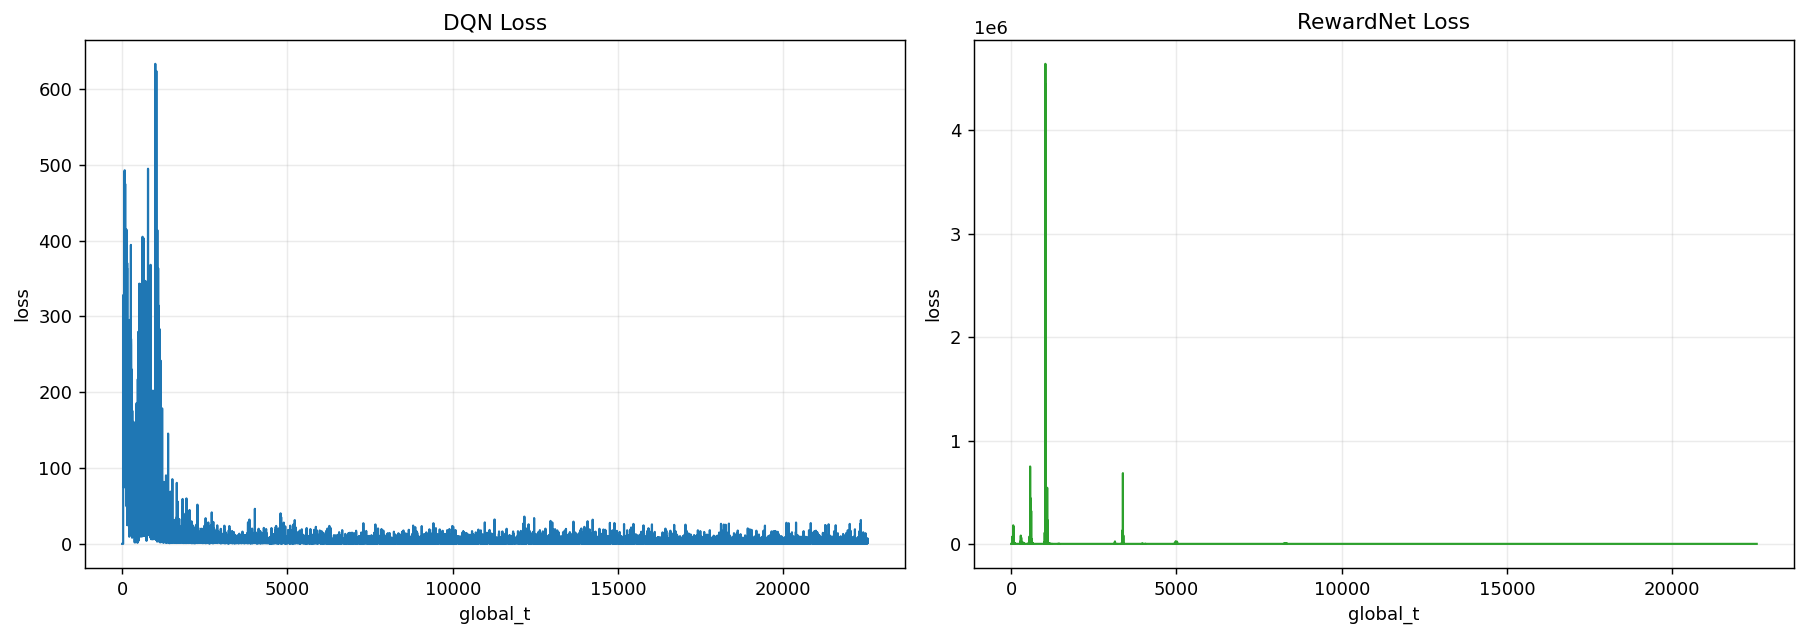

,step,dqn_loss_last,reward_net_loss_last,dqn_loss_mean_1k,reward_net_loss_mean_1k,val_clicks_sum
0,5000,2.422728,348.457947,26.392582,4064.382434,489.611168
1,10000,5.751985,0.088379,3.156628,25.894552,489.534998
2,15000,1.385348,0.271283,3.010206,1.197216,489.534998
3,20000,0.941641,0.021106,2.770559,0.075685,486.908855


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=130)

axes[0].plot(diagnostics_df['global_t'], diagnostics_df['dqn_loss'], color='#1f77b4', linewidth=1.2)
axes[0].set_title('DQN Loss')
axes[0].set_xlabel('global_t')
axes[0].set_ylabel('loss')
axes[0].grid(alpha=0.25)

axes[1].plot(diagnostics_df['global_t'], diagnostics_df['reward_net_loss'], color='#2ca02c', linewidth=1.2)
axes[1].set_title('RewardNet Loss')
axes[1].set_xlabel('global_t')
axes[1].set_ylabel('loss')
axes[1].grid(alpha=0.25)

fig.tight_layout()
plt.show()

display(
    checkpoints_df[
        ['step', 'dqn_loss_last', 'reward_net_loss_last', 'dqn_loss_mean_1k', 'reward_net_loss_mean_1k', 'val_clicks_sum']
    ]
)

## LinearBidder train-tuned validation check

LinearBidder has no gradient fit loop; the train-side learning signal is Optuna parameter search. Each trial is scored on train and immediately re-evaluated on validation with the same parameters.


In [10]:
# linear_study, linear_trials_df, linear_best_train_row, linear_best_val_row = run_linear_train_val_trials(
#       train_split=splits['train'],
#       val_split=splits['val'],
#       auction_mode=AUCTION_MODE,
#       n_trials=LINEAR_N_TRIALS,
#       random_seed=LINEAR_RANDOM_SEED,
#   )

# display(linear_trials_df.tail())
# display(linear_best_train_row.to_frame('best_train').T)
# display(linear_best_val_row.to_frame('best_val').T)

In [11]:
# fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=130)

# plot_df = linear_trials_df[linear_trials_df['stage'] == 'optuna'].sort_values('trial')
# axes[0].plot(plot_df['trial'], plot_df['train_clicks_sum'], marker='o', linewidth=1.2, label='train')
# axes[0].plot(plot_df['trial'], plot_df['val_clicks_sum'], marker='o', linewidth=1.2, label='val')
# axes[0].axhline(linear_trials_df.loc[linear_trials_df['stage'] == 'default', 'val_clicks_sum'].iloc[0], color='#777777', linestyle='--', linewidth=1.0, label='default val')
# axes[0].set_title('LinearBidder Clicks by Trial')
# axes[0].set_xlabel('trial')
# axes[0].set_ylabel('clicks_sum')
# axes[0].grid(alpha=0.25)
# axes[0].legend()

# axes[1].scatter(plot_df['train_clicks_sum'], plot_df['val_clicks_sum'], s=36, alpha=0.8)
# axes[1].set_title('Train vs Val Clicks')
# axes[1].set_xlabel('train_clicks_sum')
# axes[1].set_ylabel('val_clicks_sum')
# axes[1].grid(alpha=0.25)

# fig.tight_layout()
# plt.show()
